Task A — Dataset Preparation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
# Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Original training images:", x_train_full.shape)
print("Original training labels:", y_train_full.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1843s 11us/step
Original training images: (50000, 32, 32, 3)
Original training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


In [ ]:
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Number of classes:", len(class_names))
print("Classes:", class_names)

Number of classes: 10
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
# Convert pixel values from 0-255 to 0-1
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train_full.min())
print("Maximum pixel value:", x_train_full.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
# Split original training data into 80% training and 20% validation
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

print("Training data:", x_train.shape)
print("Validation data:", x_val.shape)
print("Testing data:", x_test.shape)

Training data: (40000, 32, 32, 3)
Validation data: (10000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


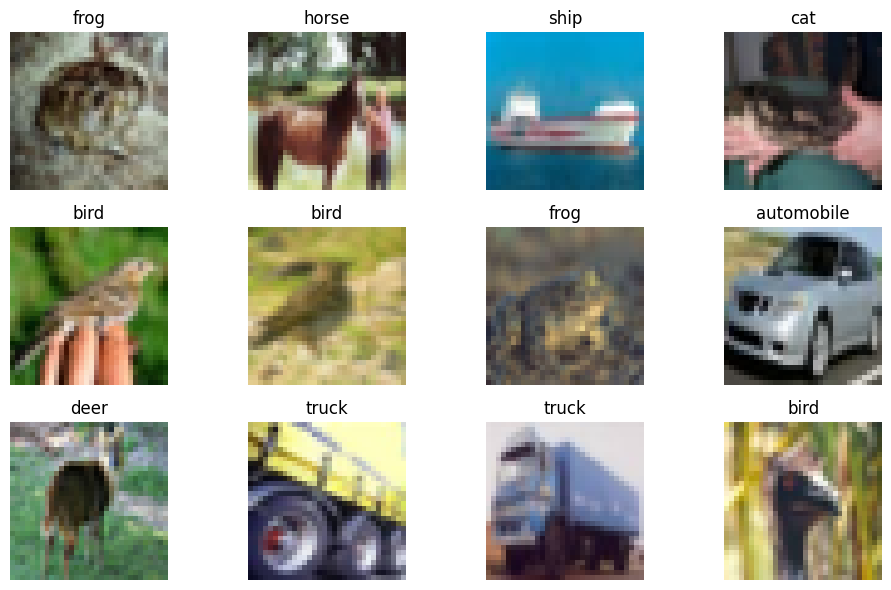

In [ ]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Task B — CNN Model Implementation

In [ ]:
model = models.Sequential([

    # Input layer
    layers.Input(shape=(32, 32, 3)),

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),

    # Output layer
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


Task C — Model Training and Evaluation

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 107ms/step - accuracy: 0.4108 - loss: 1.6098 - val_accuracy: 0.5054 - val_loss: 1.3804
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 98ms/step - accuracy: 0.5591 - loss: 1.2359 - val_accuracy: 0.6036 - val_loss: 1.1366
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.6189 - loss: 1.0814 - val_accuracy: 0.6259 - val_loss: 1.0719
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.6647 - loss: 0.9575 - val_accuracy: 0.6408 - val_loss: 1.0180
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 95ms/step - accuracy: 0.6907 - loss: 0.8815 - val_accuracy: 0.6776 - val_loss: 0.9326
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.7192 - loss: 0.8091 - val_accuracy: 0.6917 - val_loss: 0.8957
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.7409 - loss: 0.7461 - val_accuracy: 0.6884 - val_loss: 0.9220
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 97ms/step - accuracy: 0.7615 - loss: 0.6881 -

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7042 - loss: 1.0157

Test Loss: 1.0156620740890503
Test Accuracy: 0.704200029373169
Test Accuracy (%): 70.4200029373169


In [ ]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

print("Final Training Accuracy:", train_accuracy[-1])
print("Final Validation Accuracy:", val_accuracy[-1])
print("Final Training Loss:", train_loss[-1])
print("Final Validation Loss:", val_loss[-1])

Final Training Accuracy: 0.8656749725341797
Final Validation Accuracy: 0.7056999802589417
Final Training Loss: 0.3857916295528412
Final Validation Loss: 1.0043624639511108


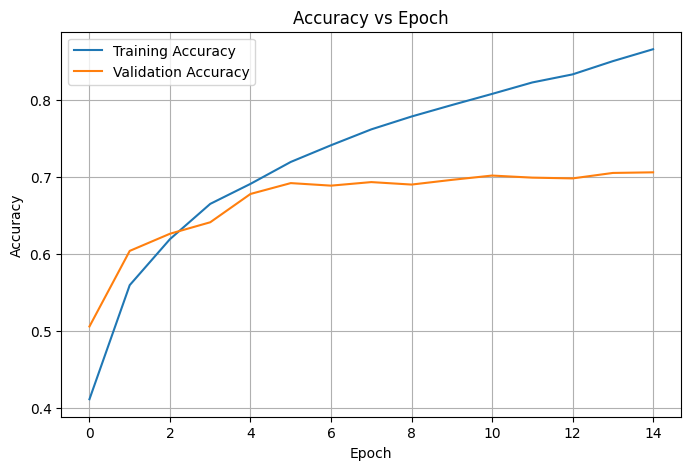

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

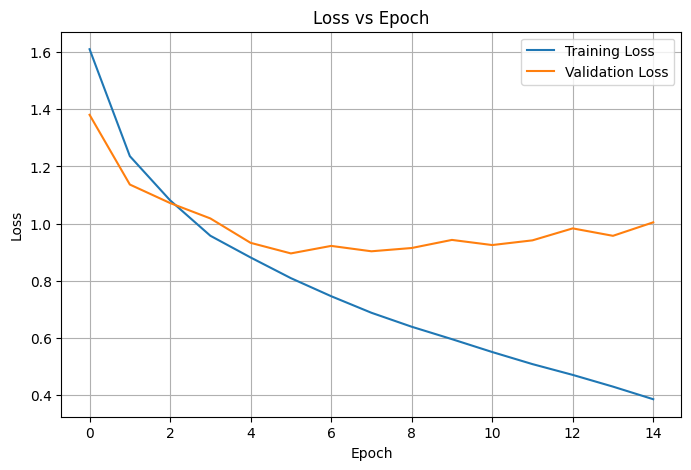

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Task D — Performance Analysis

In [ ]:
# Generate probability predictions
predictions = model.predict(x_test)

# Convert probabilities into class numbers
y_pred = np.argmax(predictions, axis=1)

# Convert actual labels into 1D format
y_true = y_test.flatten()

print("Predictions shape:", y_pred.shape)
print("Actual labels shape:", y_true.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Predictions shape: (10000,)
Actual labels shape: (10000,)


<Figure size 1000x800 with 0 Axes>

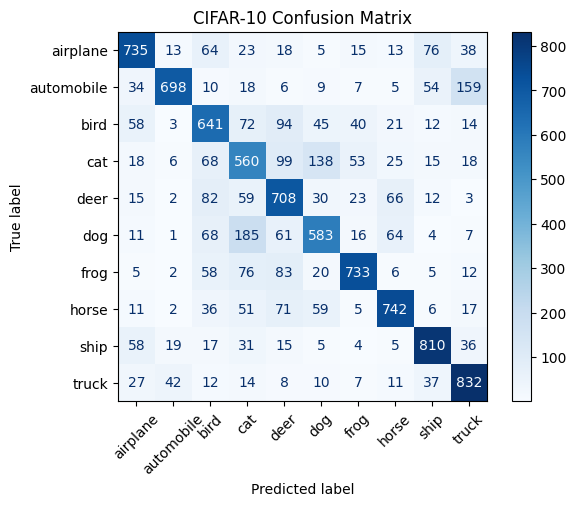

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap='Blues',
    xticks_rotation=45
)

plt.title("CIFAR-10 Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

    airplane       0.76      0.73      0.75      1000
  automobile       0.89      0.70      0.78      1000
        bird       0.61      0.64      0.62      1000
         cat       0.51      0.56      0.54      1000
        deer       0.61      0.71      0.65      1000
         dog       0.64      0.58      0.61      1000
        frog       0.81      0.73      0.77      1000
       horse       0.77      0.74      0.76      1000
        ship       0.79      0.81      0.80      1000
       truck       0.73      0.83      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.71     10000
weighted avg       0.71      0.70      0.71     10000



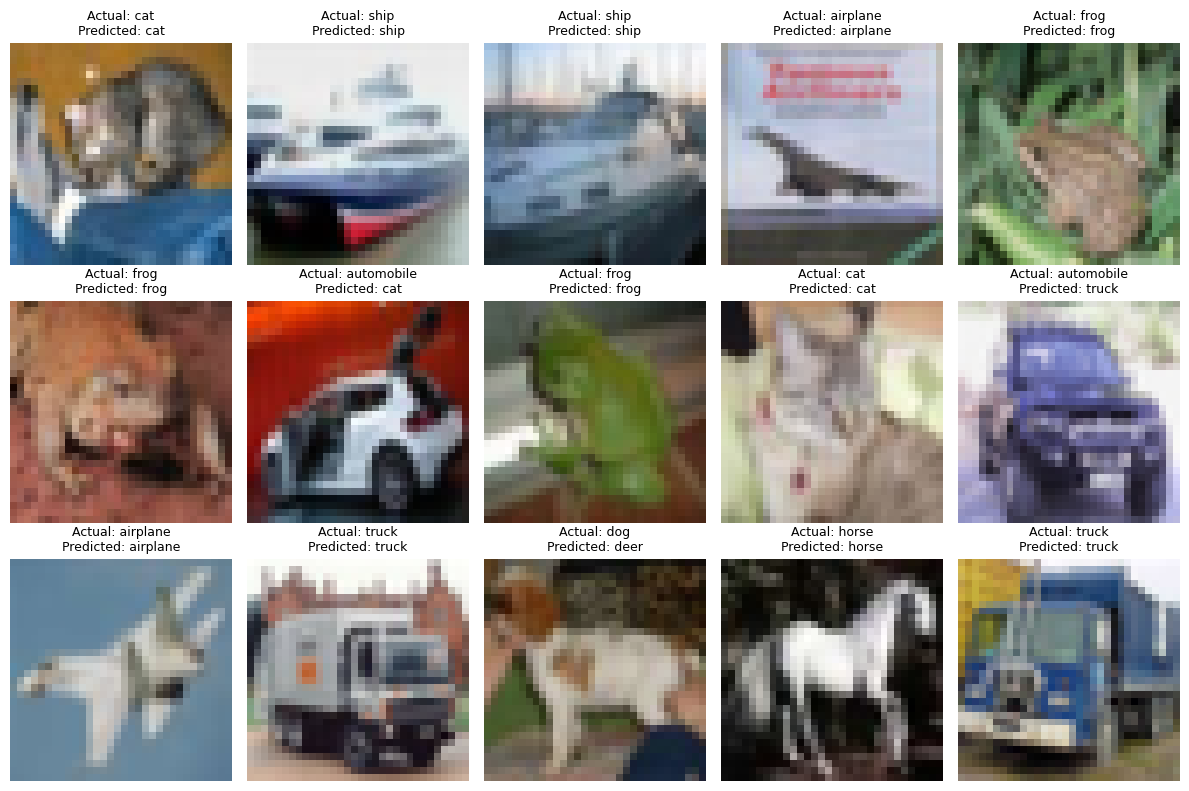

In [ ]:
plt.figure(figsize=(12, 8))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]

    if actual == predicted:
        title = f"Actual: {actual}\nPredicted: {predicted}"
    else:
        title = f"Actual: {actual}\nPredicted: {predicted}"

    plt.title(title, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Find indexes of incorrectly classified images
misclassified_indices = np.where(y_true != y_pred)[0]

print("Total misclassified images:", len(misclassified_indices))
print("Misclassification percentage:",
      (len(misclassified_indices) / len(y_true)) * 100)

Total misclassified images: 2958
Misclassification percentage: 29.580000000000002


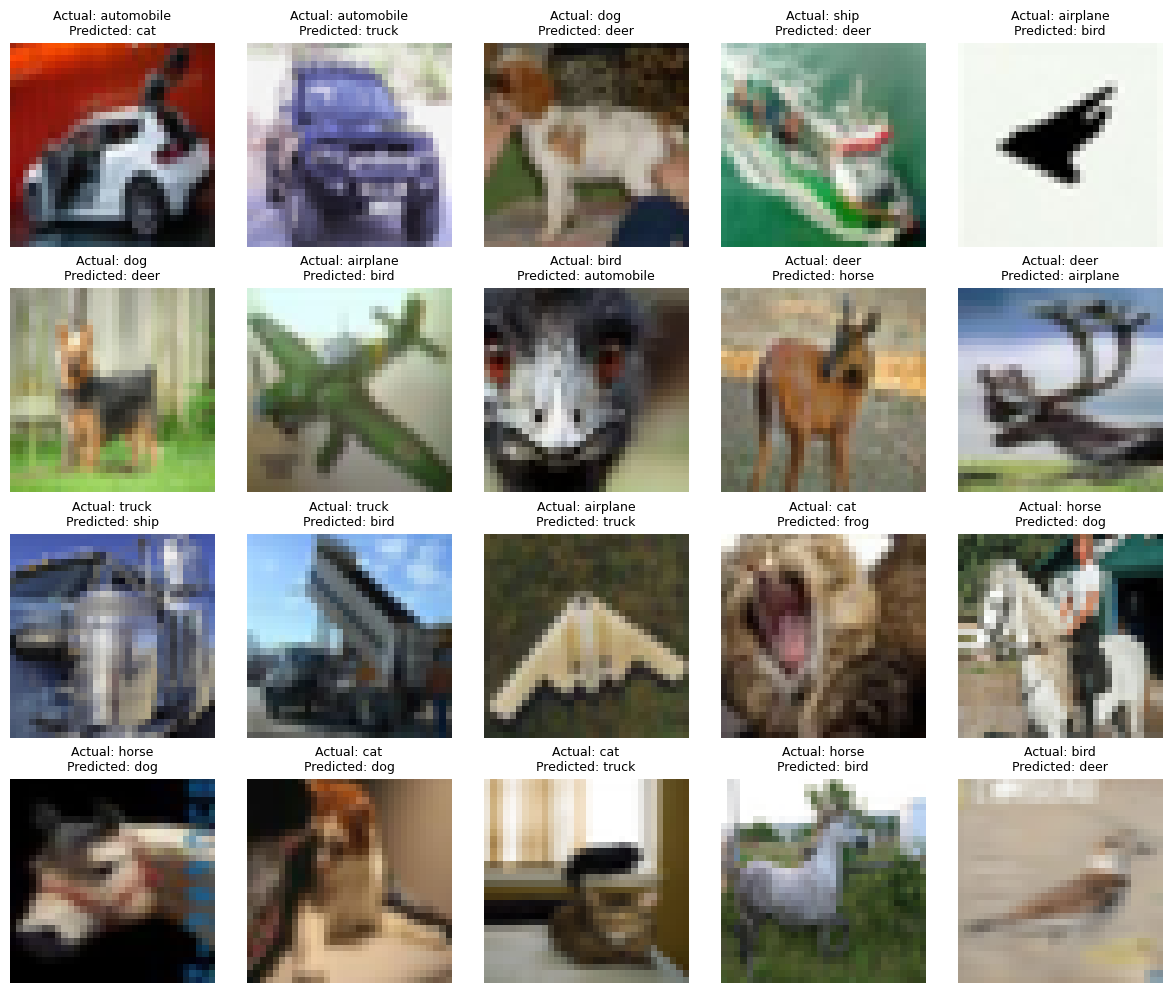

In [ ]:
plt.figure(figsize=(12, 10))

num_images = min(20, len(misclassified_indices))

for i in range(num_images):
    index = misclassified_indices[i]

    plt.subplot(4, 5, i + 1)

    plt.imshow(x_test[index])

    actual = class_names[y_true[index]]
    predicted = class_names[y_pred[index]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Create a list of misclassified class pairs
misclassified_pairs = []

for i in misclassified_indices:
    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]
    misclassified_pairs.append((actual, predicted))

# Count each type of error
from collections import Counter

error_counts = Counter(misclassified_pairs)

print("Most common misclassifications:\n")

for pair, count in error_counts.most_common(15):
    print(f"{pair[0]} → {pair[1]} : {count}")

Most common misclassifications:

dog → cat : 185
automobile → truck : 159
cat → dog : 138
cat → deer : 99
bird → deer : 94
frog → deer : 83
deer → bird : 82
frog → cat : 76
airplane → ship : 76
bird → cat : 72
horse → deer : 71
cat → bird : 68
dog → bird : 68
deer → horse : 66
airplane → bird : 64


In [ ]:
print("=" * 50)
print("CNN IMAGE CLASSIFICATION RESULTS")
print("=" * 50)

print(f"Training Accuracy   : {train_accuracy[-1] * 100:.2f}%")
print(f"Validation Accuracy : {val_accuracy[-1] * 100:.2f}%")
print(f"Training Loss       : {train_loss[-1]:.4f}")
print(f"Validation Loss     : {val_loss[-1]:.4f}")
print(f"Testing Accuracy    : {test_accuracy * 100:.2f}%")
print("=" * 50)

CNN IMAGE CLASSIFICATION RESULTS
Training Accuracy   : 86.57%
Validation Accuracy : 70.57%
Training Loss       : 0.3858
Validation Loss     : 1.0044
Testing Accuracy    : 70.42%
